## Principles of Machine Learning Final Project
**By: Saheli Ray, Wyatt Golden, HuiDi Hu, Ayam Agarwal**

For this project, we built a machine-learning model for predicting whether a wildlife strike caused aircraft damage. It is organized into three main sections: **Data Exploration**, **Data Cleaning / Feature Engineering**, and **Modeling**.

In [10]:
# All imports needed for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns = 100


## Data Exploration

In this section of the notebook, we take a look at the data and try to figure out these three questions:

1. **What does the target look like?** We check class balance for `INDICATED_DAMAGE` to see we need to take into consideration class imbalance.
2. **Which raw fields appear useful?** We compare damage rates across flight phase, bird size, time of day, month, and encounter-size fields, then compare numeric distributions for speed, height, distance, and aircraft mass.
3. **How much missing data is present?** We inspect both overall missingness and missingness in candidate predictor fields to decide which columns should be dropped, imputed, or converted into missing-value indicators.

The main result is that the data is strongly imbalanced. Domain variables such as `PHASE_OF_FLIGHT`, `SIZE`, `NUM_STRUCK`, `SPEED`, `HEIGHT`, `DISTANCE`, and `INCIDENT_MONTH` show patterns related to damage. Missingness is also not random for several numeric fields, so we keep missingness indicators instead of silently filling everything and losing that signal.


In [11]:
# Load dataset and look at its shape and first 5 rows
train = pd.read_csv("train.csv", low_memory=False)
print("Dataset shape:", train.shape)
train.head(5)

Dataset shape: (307178, 55)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,SKY,PRECIPITATION,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,7,PR,ASO,NaN,AAL,AMERICAN AIRLINES,N892AA,NaN,B-727-200,148,11,34.0,10.0,A,4.0,D,3.0,5.0,6.0,5.0,NaN,Approach,300.0,145.0,NaN,Some Cloud,NaN,NaN,UNKBS,Unknown bird - small,0,NO SIGN OF BIRD ON A/C.,1,0,No,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,32R,FN,FGN,NaN,FDX,FEDEX EXPRESS,N608FE,5293,MD-11,583,39,22.0,7.0,A,4.0,D,3.0,1.0,6.0,1.0,NaN,Approach,50.0,NaN,0.0,NaN,NaN,NaN,UNKBM,Unknown bird - medium,0,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,0,0,Unknown,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,35L,KY,ASO,NaN,UPS,UPS AIRLINES,N141UP,907,A-300,04A,1,34.0,46.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Approach,3500.0,240.0,8.0,NaN,NaN,NaN,UNKBL,Unknown bird - large,0,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",0,0,No,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,25R,CA,AWP,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NE120,Western gull,0,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,1,0,Unknown,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,35,HI,AWP,NaN,1AAH,ALOHA AIRLINES,NaN,NaN,B-737-200,148,13,34.0,10.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Landing Roll,0.0,135.0,0.0,Some Cloud,NaN,NaN,R1101,American barn owl,0,TIME 0824 LCL.,0,0,No,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


Each graph answers a different EDA question: class balance, feature missingness, categorical damage-rate differences, monthly/seasonal behavior, numeric separation by damage class, and whether missing numeric values are themselves predictive.

Training shape: (307178, 55)
Target damage rate: 0.0636


,count
INDICATED_DAMAGE,
0,287651
1,19527


Top columns by missing percentage


,missing_percent
BIRD_BAND_NUMBER,99.767887
ENG_4_POS,98.935796
ENROUTE_STATE,98.259641
PRECIPITATION,96.349999
ENG_3_POS,95.977577
LOCATION,87.232810
SPEED,69.040101
NUM_SEEN,67.890930
SKY,53.006726
FLT,52.554219


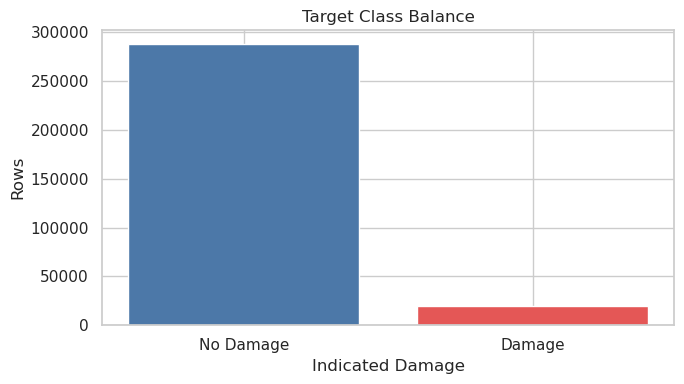

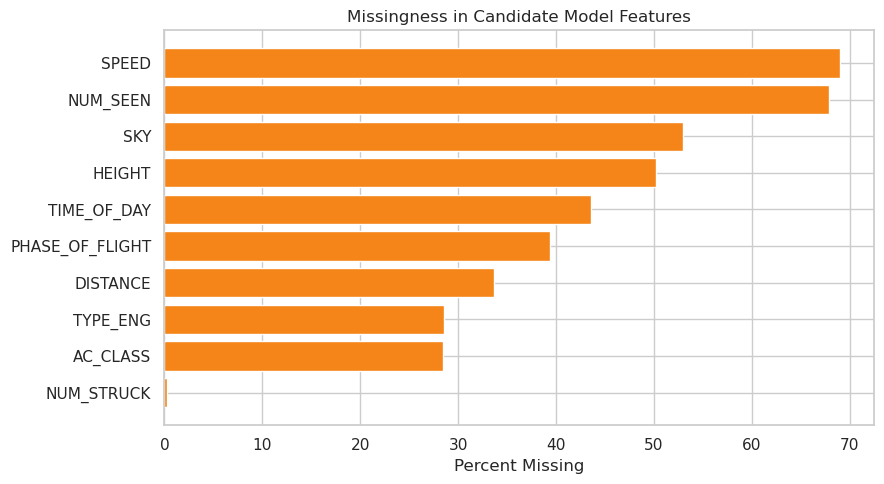

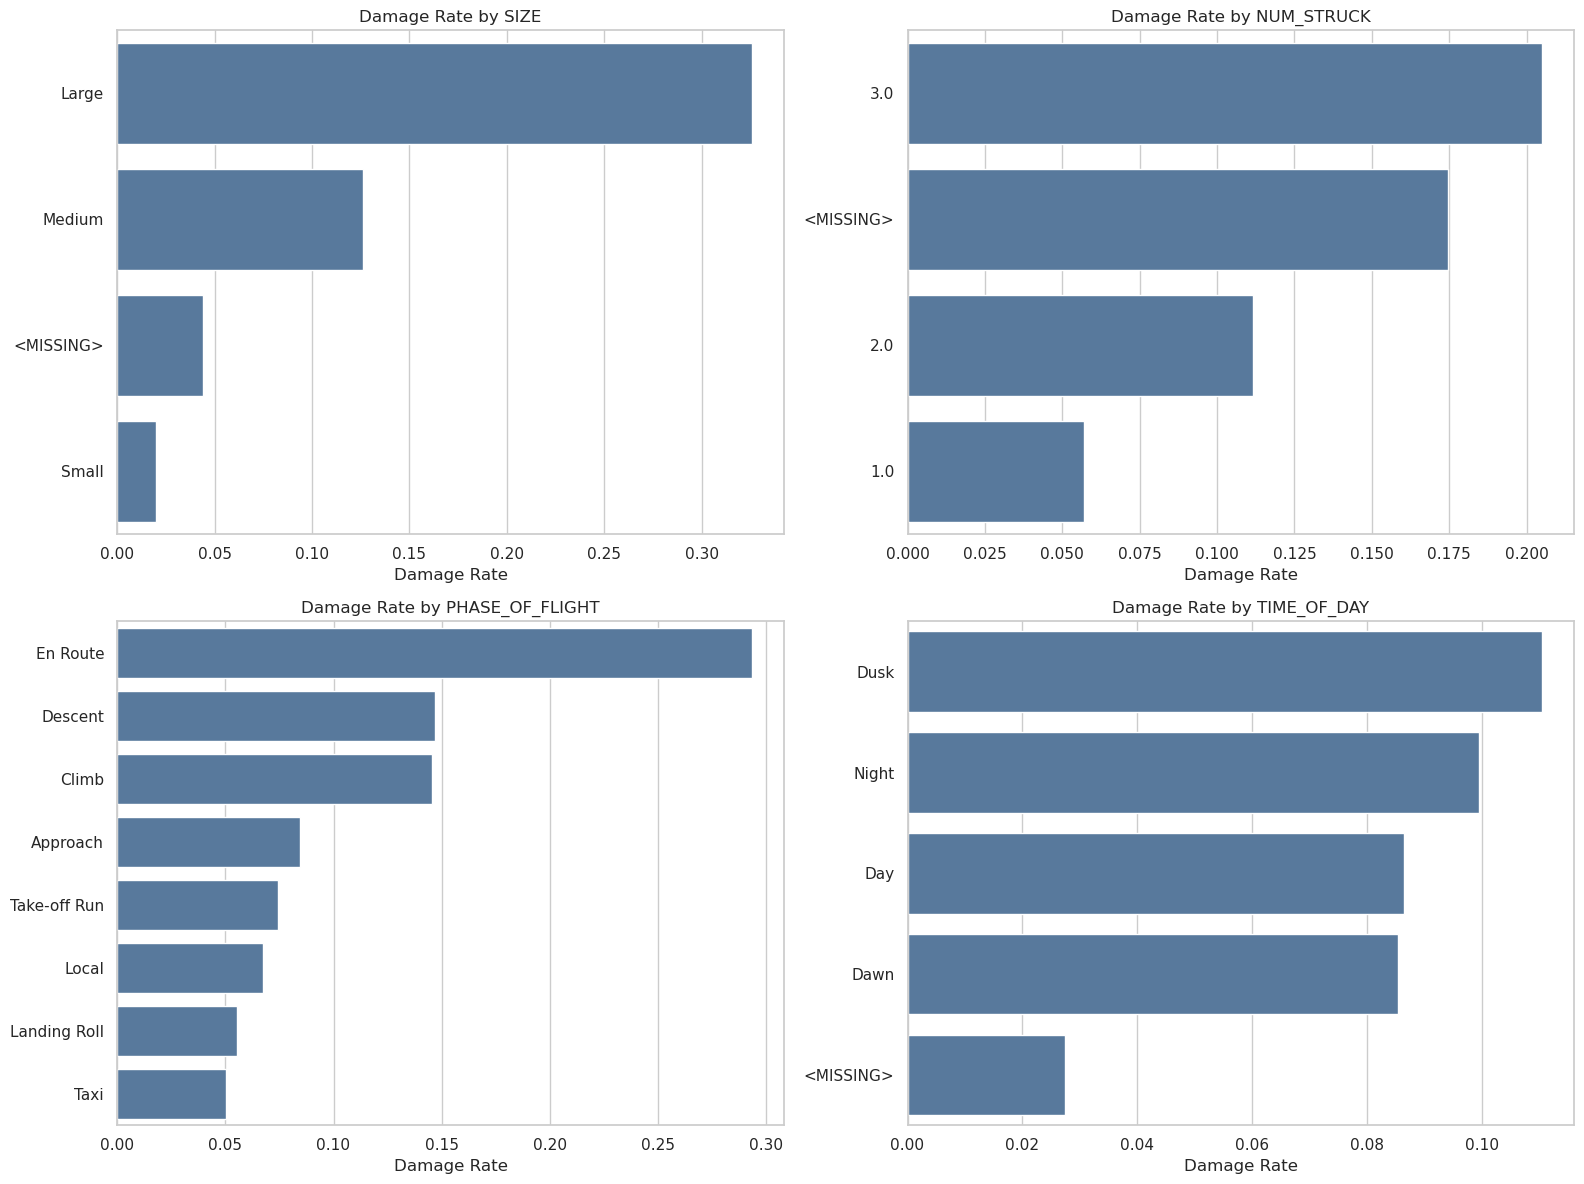

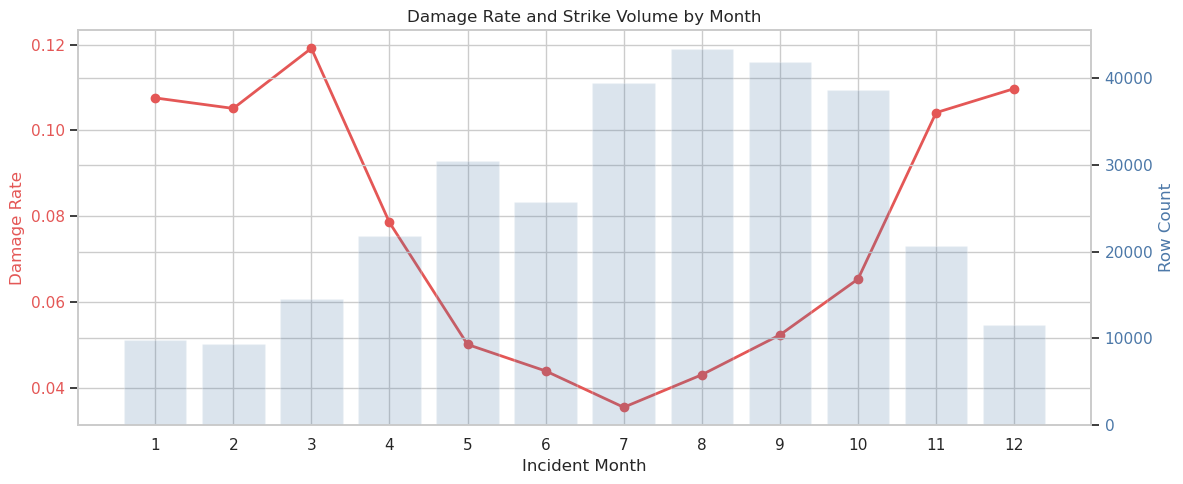

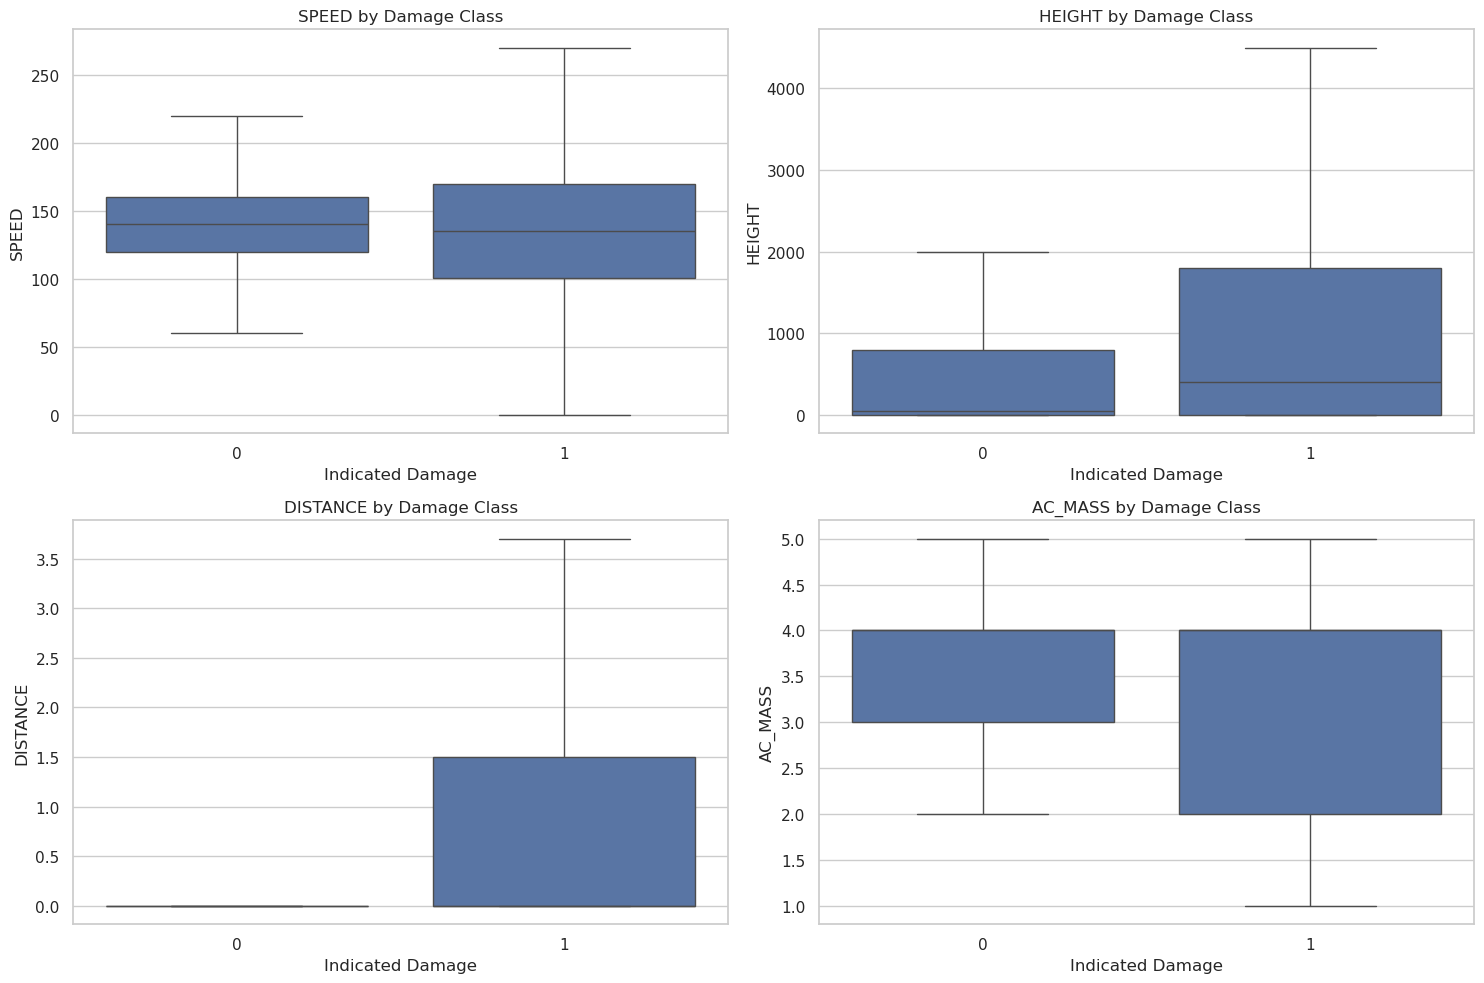

In [12]:
sns.set_theme(style="whitegrid")

# Columns selected for EDA
eda_columns = [
    "INDICATED_DAMAGE", "LATITUDE", "LONGITUDE", "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
    "SPEED", "HEIGHT", "DISTANCE", "SIZE", "NUM_STRUCK", "NUM_SEEN", "PHASE_OF_FLIGHT",
    "TIME_OF_DAY", "SKY", "WARNED", "INCIDENT_MONTH", "FAAREGION"
]

eda = train[eda_columns].copy()

# Numeric Columns selected for EDA
numeric_eda_columns = [
    "LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH"
]
for col in numeric_eda_columns:
    eda[col] = pd.to_numeric(eda[col], errors="coerce")

# Corrects data corruption for the NUM_STRUCK and NUM_SEEN columns
encounter_size_map = {
    "1": 1,
    "10-Feb": 2,
    "2-10": 2,
    "Feb-10": 2,
    "11-100": 3,
    "More than 100": 4,
}
for col in ["NUM_SEEN", "NUM_STRUCK"]:
    eda[col] = eda[col].replace(encounter_size_map)
    eda[col] = pd.to_numeric(eda[col], errors="coerce")

# Categorical Columns selected for EDA
categorical_eda_columns = [
    "AC_CLASS", "TYPE_ENG", "SIZE", "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "FAAREGION"
]
for col in categorical_eda_columns:
    eda[col] = eda[col].replace(r"^\s*$", np.nan, regex=True)

# Look at the shape, target balance, and missingness in the EDA columns.
print("Training shape:", train.shape)
print("Target damage rate:", round(eda["INDICATED_DAMAGE"].mean(), 4))
display(eda["INDICATED_DAMAGE"].value_counts().rename("count").to_frame())

# Missingness in the EDA columns out of entire dataset
missing_percent = (train.isna().mean() * 100).sort_values(ascending=False)
print("Top columns by missing percentage")
display(missing_percent.head(20).rename("missing_percent").to_frame())

# Graph 1: Target class balance shows why plain accuracy is not enough for this project.
class_counts = eda["INDICATED_DAMAGE"].value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar(["No Damage", "Damage"], class_counts.values, color=["#4C78A8", "#E45756"], edgecolor="white")
plt.title("Target Class Balance")
plt.xlabel("Indicated Damage")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

# Graph 2: Candidate-feature missingness shows which modeling fields need imputation or missing indicators.
missing_candidates = [
    "SPEED", "HEIGHT", "DISTANCE", "NUM_SEEN", "NUM_STRUCK", "TIME_OF_DAY",
    "PHASE_OF_FLIGHT", "SKY", "TYPE_ENG", "AC_CLASS"
]
missing_rates = eda[missing_candidates].isna().mean().sort_values()
plt.figure(figsize=(9, 5))
plt.barh(missing_rates.index, missing_rates.values * 100, color="#F58518", edgecolor="white")
plt.title("Missingness in Candidate Model Features")
plt.xlabel("Percent Missing")
plt.tight_layout()
plt.show()

# Graph 3: Categorical damage rates identify domain groups with different damage risk.
plot_columns = ["SIZE", "NUM_STRUCK", "PHASE_OF_FLIGHT", "TIME_OF_DAY"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, column in zip(axes.flat, plot_columns):
    summary = damage_rate_table(column).head(8)
    sns.barplot(data=summary.reset_index(), x="damage_rate", y=column, ax=ax, color="#4C78A8")
    ax.set_title(f"Damage Rate by {column}")
    ax.set_xlabel("Damage Rate")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Graph 4: Monthly damage rate with row counts motivates seasonal and cyclical month features.
month_damage = eda.groupby("INCIDENT_MONTH")["INDICATED_DAMAGE"].mean().reindex(range(1, 13))
month_counts = eda.groupby("INCIDENT_MONTH").size().reindex(range(1, 13), fill_value=0)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(month_damage.index, month_damage.values, marker="o", color="#E45756", linewidth=2)
ax1.set_title("Damage Rate and Strike Volume by Month")
ax1.set_xlabel("Incident Month")
ax1.set_ylabel("Damage Rate", color="#E45756")
ax1.tick_params(axis="y", labelcolor="#E45756")
ax1.set_xticks(range(1, 13))
ax2 = ax1.twinx()
ax2.bar(month_counts.index, month_counts.values, alpha=0.2, color="#4C78A8")
ax2.set_ylabel("Row Count", color="#4C78A8")
ax2.tick_params(axis="y", labelcolor="#4C78A8")
plt.tight_layout()
plt.show()

# Graph 5: Numeric distributions by damage class show which continuous fields carry separation.
numeric_plot_columns = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, column in zip(axes.flat, numeric_plot_columns):
    subset = eda[[column, "INDICATED_DAMAGE"]].dropna()
    sampled_subset = subset.groupby("INDICATED_DAMAGE", group_keys=False).apply(
        lambda x: x.sample(min(len(x), 6000), random_state=42)
    )
    sns.boxplot(data=sampled_subset, x="INDICATED_DAMAGE", y=column, ax=ax, showfliers=False)
    ax.set_title(f"{column} by Damage Class")
    ax.set_xlabel("Indicated Damage")
plt.tight_layout()
plt.show()


### Data Exploration Results

The exploration led to several modeling decisions:

- **Class imbalance:** Most strikes did not indicate damage. This is why the modeling section tunes thresholds using balanced accuracy and reports recall/F1 instead of relying only on accuracy.
- **Flight context matters:** `PHASE_OF_FLIGHT`, `HEIGHT`, `SPEED`, and `DISTANCE` capture where the aircraft was in the flight profile. The damage rates and numeric distributions differed enough to keep both raw values and binned versions.
- **Animal/encounter severity matters:** Larger birds and multi-bird encounters had higher damage risk, motivating `SIZE_NUM`, `MULTI_STRIKE`, `STRIKE_RATIO`, `FLOCK_EXPOSURE`, and size-by-speed/mass/height interaction features.
- **Time and geography matter:** Month showed a seasonal pattern, and location fields may capture regional wildlife and airport-environment differences. This motivated raw `INCIDENT_MONTH`, cyclical month features, `SEASON`, `STATE`, `FAAREGION`, `LATITUDE`, and `LONGITUDE`.
- **Missingness is informative:** `SPEED`, `HEIGHT`, and `DISTANCE` were not simply random blanks. We therefore keep `SPEED_MISSING`, `HEIGHT_MISSING`, and `DISTANCE_MISSING` before imputing values.
- **Some columns are too risky or sparse:** Identifier-like, free-text, extremely sparse, or post-event investigation fields were excluded because they would either overfit, add noise, or leak information that would not be appropriate for prediction.


## Data Cleaning / Feature Engineering

This section turns the raw FAA wildlife-strike rows into a modeling table. The cleaning choices are based on the EDA above plus domain knowledge about what information would be available and meaningful before predicting damage.

### Columns Completely Discarded as Raw Predictors

- `BIRD_BAND_NUMBER`, `ENG_3_POS`, and `ENG_4_POS`: almost entirely missing.
- `INDEX_NR`, `LUPDATE`, and `TRANSFER`: identifiers or misc fields rather than predictive aircraft/strike information.
- `REG`, `FLT`, `AIRPORT_ID`, `AIRPORT`, `OPID`, `OPERATOR`, `AMA`, `AMO`, `EMA`, and `EMO`: high-cardinality identifiers that could memorize training rows or duplicate cleaner aircraft fields.
- `REMARKS`, `COMMENTS`, `LOCATION`, and `ENROUTE_STATE`: free-text or sparse fields that would require a separate NLP workflow and could easily overfit.
- `INCIDENT_DATE`: too granular; we keep `INCIDENT_MONTH`, `MONTH_SIN`, `MONTH_COS`, `SEASON`, and `INCIDENT_YEAR` instead.
- `SPECIES`: removed because it duplicates `SPECIES_ID` as a longer text label.
- `ENG_1_POS`, `ENG_2_POS`, and `HAS_WING_MOUNTED_ENGINES`: earlier engine-position features were sparse or did not improve validation accuracy enough to keep.
- `REMAINS_COLLECTED` and `REMAINS_SENT`: removed because they are post-event investigation fields and may leak information gathered after the strike.
- Raw `PRECIPITATION`: about 96% missing, so we keep only a compact `HAS_PRECIPITATION` flag.

### Missing Values

- Blank categorical values are converted to `Unknown` so missingness can remain visible to tree models.
- `HEIGHT` and `SPEED` are imputed using medians within `PHASE_OF_FLIGHT`, because normal speed/height depends heavily on whether the aircraft is taking off, landing, climbing, cruising, or on the ground.
- `DISTANCE` is imputed with the global median because it is useful but does not have the same clear phase-specific interpretation.
- `SPEED_MISSING`, `HEIGHT_MISSING`, and `DISTANCE_MISSING` are created before imputation because the EDA showed missingness itself can carry signal.
- Rows missing `INDICATED_DAMAGE` are dropped because they do not provide labels for supervised training.

### Engineered Features Kept

- Cyclical time features: `MONTH_SIN`, `MONTH_COS`, and `SEASON`.
- Nonlinear bins: `HEIGHT_BAND`, `SPEED_BAND`, and `DISTANCE_BAND`.
- Encounter severity: decoded `NUM_STRUCK`, decoded `NUM_SEEN`, `MULTI_STRIKE`, `STRIKE_RATIO`, and `FLOCK_EXPOSURE`.
- Domain interactions: `SIZE_X_MASS`, `SIZE_X_SPEED`, `SIZE_X_HEIGHT`, `LARGE_BIRD_SMALL_AIRCRAFT`, `HIGH_RISK_ENROUTE`, and `WARNED_LARGE_BIRD`.
- High-cardinality support: frequency encodings for `SPECIES_ID`, `AIRCRAFT`, and `STATE`, while also allowing the tree pipelines to use grouped one-hot/ordinal encodings.

### Earlier Ideas Not Kept

We previously tried simplifying away raw `HEIGHT`, `SPEED`, and `INCIDENT_MONTH` after creating bins/interactions, but validation accuracy was better when the raw values were restored. We also tried using raw engine-position fields and a wing-mounted-engine flag, but those features were too sparse or did not improve accuracy enough. More aggressive neural-network tuning with nested cross validation was also tested, but it was slow, duplicated preprocessing code, and showed overfitting on the minority class, so we kept only a simpler imbalance-aware neural network only as a comparison model.

In [13]:
# Raw columns that are allowed into cleaning. Some are used only to build engineered features.
selected_columns = [
    "LATITUDE", "LONGITUDE", "STATE", "FAAREGION",
    "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS", "AIRCRAFT",
    "SPEED", "HEIGHT", "DISTANCE",
    "SIZE", "SPECIES_ID", "NUM_STRUCK", "NUM_SEEN",
    "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "PRECIPITATION", "WARNED",
    "INCIDENT_MONTH", "INCIDENT_YEAR",
    "SOURCE", "PERSON", "REMAINS_COLLECTED", "REMAINS_SENT",
    "INDICATED_DAMAGE",  # Target variable
]

# Columns that are not used as raw predictors but are still important for EDA and feature engineering.
columns_excluded_as_raw_predictors = [
    "BIRD_BAND_NUMBER", "INDEX_NR", "REG", "FLT", "REMARKS", "COMMENTS", "LOCATION",
    "ENROUTE_STATE", "LUPDATE", "TRANSFER", "INCIDENT_DATE", "AIRPORT_ID", "AIRPORT",
    "OPID", "OPERATOR", "AMA", "AMO", "EMA", "EMO", "SPECIES", "ENG_1_POS", "ENG_2_POS",
    "ENG_3_POS", "ENG_4_POS", "HAS_WING_MOUNTED_ENGINES", "REMAINS_COLLECTED", "REMAINS_SENT",
    "PRECIPITATION",
]

# Final predictor columns after cleaning and feature engineering.
raw_numeric_features = [
    "LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "DISTANCE", "INCIDENT_YEAR", "INCIDENT_MONTH",
    "HEIGHT", "SPEED", "NUM_STRUCK", "NUM_SEEN",
]
engineered_numeric_features = [
    "MONTH_SIN", "MONTH_COS", "SPEED_AC_MASS", "HEIGHT_SPEED", "IS_GROUND_STRIKE",
    "MULTI_STRIKE", "IS_LARGE_AIRCRAFT", "SPEED_MISSING", "HEIGHT_MISSING", "DISTANCE_MISSING",
    "SPECIES_ID_FREQ", "AIRCRAFT_FREQ", "STATE_FREQ", "SIZE_NUM", "SIZE_X_MASS", "SIZE_X_SPEED",
    "SIZE_X_HEIGHT", "LARGE_BIRD_SMALL_AIRCRAFT", "HIGH_RISK_ENROUTE", "STRIKE_RATIO",
    "FLOCK_EXPOSURE", "WARNED_LARGE_BIRD", "HAS_PRECIPITATION",
]
numeric_features = raw_numeric_features + engineered_numeric_features
categorical_features = [
    "AC_CLASS", "TYPE_ENG", "AIRCRAFT", "SIZE", "SPECIES_ID", "PHASE_OF_FLIGHT", "TIME_OF_DAY",
    "SKY", "WARNED", "STATE", "FAAREGION", "SEASON", "HEIGHT_BAND", "SPEED_BAND",
    "DISTANCE_BAND", "SOURCE", "PERSON",
]

raw_feature_columns = [col for col in selected_columns if col != "INDICATED_DAMAGE"]
feature_columns = numeric_features + categorical_features

# Used to map the Excel-misread encounter size ranges in NUM_STRUCK and NUM_SEEN to ordinal numeric values.
encounter_size_map = {
    "1": 1,
    "10-Feb": 2,
    "2-10": 2,
    "Feb-10": 2,
    "11-100": 3,
    "More than 100": 4,
}

# Used to map SIZE categories to ordinal numeric values for feature engineering.
size_order = {
    "Small": 1,
    "Medium": 2,
    "Large": 3,
    "Unknown": 0,
}

phase_numeric_imputation_values = {}
frequency_encoding_maps = {}

# Turns numeric month into categorical season
def month_to_season(month):
    if pd.isna(month):
        return "Unknown"
    month = int(month)
    if month in [1, 2, 3]:
        return "Winter"
    if month in [4, 5, 6]:
        return "Spring"
    if month in [7, 8, 9]:
        return "Summer"
    if month in [10, 11, 12]:
        return "Fall"
    return "Unknown"

# Bins height into categories
def bin_height(height):
    if pd.isna(height):
        return "Unknown"
    if height == 0:
        return "Ground"
    if height <= 100:
        return "Low"
    if height <= 1000:
        return "Pattern"
    if height <= 5000:
        return "Climb/Descent"
    return "High"

# Bins speed into categories
def bin_speed(speed):
    if pd.isna(speed):
        return "Unknown"
    if speed <= 80:
        return "Slow"
    if speed <= 160:
        return "Moderate"
    if speed <= 250:
        return "Fast"
    return "Very Fast"

# Bins distance into categories
def bin_distance(distance):
    if pd.isna(distance):
        return "Unknown"
    if distance == 0:
        return "At Airport"
    if distance <= 5:
        return "Near Airport"
    if distance <= 20:
        return "Terminal Area"
    return "Far"

# Adds frequency encodings for high-cardinality categorical features. Maps rare or missing values to 0.
def add_frequency_encodings(cleaned, fit=False):
    global frequency_encoding_maps

    frequency_columns = ["SPECIES_ID", "AIRCRAFT", "STATE"]
    if fit:
        frequency_encoding_maps = {
            col: cleaned[col].value_counts(normalize=True) for col in frequency_columns if col in cleaned.columns
        }

    for col in frequency_columns:
        encoded_col = f"{col}_FREQ"
        if col in cleaned.columns:
            frequency_map = frequency_encoding_maps.get(col, pd.Series(dtype=float))
            cleaned[encoded_col] = cleaned[col].map(frequency_map).fillna(0)
        else:
            cleaned[encoded_col] = 0
    return cleaned

# Numeric imputation reflects that height/speed mean different things in different flight phases.
def add_domain_imputations(cleaned, fit=False):
    global phase_numeric_imputation_values

    if fit:
        phase_numeric_imputation_values = {
            "HEIGHT": {
                "group_medians": cleaned.groupby("PHASE_OF_FLIGHT")["HEIGHT"].median(),
                "global_median": cleaned["HEIGHT"].median(),
            },
            "SPEED": {
                "group_medians": cleaned.groupby("PHASE_OF_FLIGHT")["SPEED"].median(),
                "global_median": cleaned["SPEED"].median(),
            },
            "DISTANCE": {
                "global_median": cleaned["DISTANCE"].median(),
            },
        }

    for col in ["HEIGHT", "SPEED"]:
        values = phase_numeric_imputation_values.get(col, {})
        group_medians = values.get("group_medians", pd.Series(dtype=float))
        global_median = values.get("global_median", cleaned[col].median())
        phase_fill_values = cleaned["PHASE_OF_FLIGHT"].map(group_medians)
        cleaned[col] = cleaned[col].fillna(phase_fill_values).fillna(global_median)

    distance_median = phase_numeric_imputation_values.get("DISTANCE", {}).get("global_median", cleaned["DISTANCE"].median())
    cleaned["DISTANCE"] = cleaned["DISTANCE"].fillna(distance_median)
    return cleaned

# Clean a feature frame
def clean_feature_frame(df, columns, fit_imputers=False):
    # Copy only the columns we need so later cleaning does not affect the original dataframe.
    cleaned = df[columns].copy()

    # Convert coordinates and numeric strike/aircraft fields to numbers. Any invalid value becomes NaN.
    for col in ["LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH", "INCIDENT_YEAR"]:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Collapse mostly missing precipitation into a binary weather flag before categorical imputation.
    if "PRECIPITATION" in cleaned.columns:
        precipitation_values = cleaned["PRECIPITATION"].replace(r"^\s*$", np.nan, regex=True)
        cleaned["HAS_PRECIPITATION"] = (
            precipitation_values.notna()
            & ~precipitation_values.astype(str).str.strip().isin(["None", "Unknown", "nan", ""])
        ).astype(int)
    else:
        cleaned["HAS_PRECIPITATION"] = 0

    # Excel-misread encounter ranges become ordinal numeric values.
    for col in ["NUM_SEEN", "NUM_STRUCK"]:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(encounter_size_map)
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Treat blank categorical values as missing and preserve missingness as its own category.
    for col in categorical_features:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(r"^\s*$", np.nan, regex=True).fillna("Unknown").astype(str).str.strip()

    # Missingness appears informative for several sparse strike-condition fields.
    for col in ["SPEED", "HEIGHT", "DISTANCE"]:
        cleaned[f"{col}_MISSING"] = cleaned[col].isna().astype(int) if col in cleaned.columns else 1

    # Frequency encodings let trees use how common high-cardinality values are without relying only on one-hot splits.
    cleaned = add_frequency_encodings(cleaned, fit=fit_imputers)

    # Phase-aware numeric imputation reflects that height/speed mean different things in different flight phases.
    cleaned = add_domain_imputations(cleaned, fit=fit_imputers)

    # Domain feature engineering. Raw HEIGHT, SPEED, and INCIDENT_MONTH remain final predictors too.
    cleaned["MONTH_SIN"] = np.sin(2 * np.pi * cleaned["INCIDENT_MONTH"] / 12)
    cleaned["MONTH_COS"] = np.cos(2 * np.pi * cleaned["INCIDENT_MONTH"] / 12)
    cleaned["SPEED_AC_MASS"] = cleaned["SPEED"] * cleaned["AC_MASS"]
    cleaned["HEIGHT_SPEED"] = cleaned["HEIGHT"] * cleaned["SPEED"]
    cleaned["SEASON"] = cleaned["INCIDENT_MONTH"].apply(month_to_season)
    cleaned["HEIGHT_BAND"] = cleaned["HEIGHT"].apply(bin_height)
    cleaned["SPEED_BAND"] = cleaned["SPEED"].apply(bin_speed)
    cleaned["DISTANCE_BAND"] = cleaned["DISTANCE"].apply(bin_distance)
    cleaned["SIZE_NUM"] = cleaned["SIZE"].map(size_order).fillna(0)
    cleaned["SIZE_X_MASS"] = cleaned["SIZE_NUM"] * cleaned["AC_MASS"]
    cleaned["SIZE_X_SPEED"] = cleaned["SIZE_NUM"] * cleaned["SPEED"]
    cleaned["SIZE_X_HEIGHT"] = cleaned["SIZE_NUM"] * cleaned["HEIGHT"]
    cleaned["LARGE_BIRD_SMALL_AIRCRAFT"] = ((cleaned["SIZE"] == "Large") & (cleaned["AC_MASS"] <= 2)).astype(int)
    cleaned["HIGH_RISK_ENROUTE"] = ((cleaned["HEIGHT"] > 1000) & (cleaned["SPEED"] > 200)).astype(int)
    cleaned["STRIKE_RATIO"] = cleaned["NUM_STRUCK"] / (cleaned["NUM_SEEN"] + 1)
    cleaned["FLOCK_EXPOSURE"] = cleaned["NUM_SEEN"] * cleaned["NUM_STRUCK"]
    cleaned["WARNED_LARGE_BIRD"] = ((cleaned["WARNED"] == "No") & (cleaned["SIZE"] == "Large")).astype(int)
    cleaned["IS_GROUND_STRIKE"] = (cleaned["HEIGHT"] == 0).astype(int)
    cleaned["MULTI_STRIKE"] = (cleaned["NUM_STRUCK"] > 1).astype(int)
    cleaned["IS_LARGE_AIRCRAFT"] = (cleaned["AC_MASS"] >= 4).astype(int)

    return cleaned

# Prepares training data
def prepare_training_data(df):
    # Clean the training columns first so missing and malformed values are standardized.
    cleaned = clean_feature_frame(df, selected_columns, fit_imputers=True)

    # Drop rows only when the target is missing. Feature NaNs will be handled in the model pipeline.
    cleaned = cleaned.dropna(subset=["INDICATED_DAMAGE"]).copy()
    return cleaned[feature_columns + ["INDICATED_DAMAGE"]]

# Prepates prediction data
def prepare_prediction_data(df):
    # Clean the test features but keep rows with missing feature values for the imputer to fill.
    cleaned = clean_feature_frame(df, raw_feature_columns, fit_imputers=False)
    return cleaned[feature_columns]


# Build the cleaned training dataset that will be used for splitting and fitting.
train_clean = prepare_training_data(train)

# Take a quick look at the cleaned training data.
print("Excluded raw predictor columns:", columns_excluded_as_raw_predictors)
print(train_clean.shape)
print(train_clean.head())
print(train_clean.dtypes)


Excluded raw predictor columns: ['BIRD_BAND_NUMBER', 'INDEX_NR', 'REG', 'FLT', 'REMARKS', 'COMMENTS', 'LOCATION', 'ENROUTE_STATE', 'LUPDATE', 'TRANSFER', 'INCIDENT_DATE', 'AIRPORT_ID', 'AIRPORT', 'OPID', 'OPERATOR', 'AMA', 'AMO', 'EMA', 'EMO', 'SPECIES', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'HAS_WING_MOUNTED_ENGINES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'PRECIPITATION']
(307178, 52)
    LATITUDE   LONGITUDE  AC_MASS  NUM_ENGS  DISTANCE  INCIDENT_YEAR  \
0  18.439420  -66.001830      4.0       3.0       0.0           1993   
1   2.745578  101.709917      4.0       3.0       0.0           2010   
2  38.174390  -85.736000      4.0       2.0       8.0           2012   
3  33.942540 -118.408070      NaN       NaN       0.0           2002   
4  21.975980 -159.338960      4.0       2.0       0.0           1997   

   INCIDENT_MONTH  HEIGHT  SPEED  NUM_STRUCK  NUM_SEEN     MONTH_SIN  \
0              12   300.0  145.0         2.0       2.0 -2.449294e-16   
1               2    

### Feature Set Summary

The final feature set keeps a balance between raw domain variables and engineered summaries. Raw `HEIGHT`, `SPEED`, and `INCIDENT_MONTH` are retained because tree models can learn useful thresholds directly, while engineered bins and interactions provide additional nonlinear structure. High-cardinality fields such as `SPECIES_ID` and `AIRCRAFT` are kept carefully because they contain useful risk information, but the encoders group rare categories to reduce memorization.


## Modeling

This section trains several models that fit an imbalanced, mixed-type tabular dataset. Tree-based models are the best fit because they handle nonlinear thresholds, interactions, missing-value indicators, and one-hot or ordinal encoded categorical variables well. We still include a neural network as a non-tree comparison, but the main candidates are decision trees, bagged tree ensembles, boosted trees, and a soft-voting ensemble.

Every model uses the same held-out validation split. For models that output probabilities, we tune the classification threshold on the validation set to maximize balanced accuracy, which better reflects performance on both the damage and no-damage classes.


### Decision Tree

The first model is a single decision tree with fixed, conservative hyperparameters. We previously tried randomized hyperparameter tuning, but after adding the larger feature set it repeatedly crashed the kernel because cross-validation had to rebuild a large one-hot encoded matrix many times. To keep the notebook stable, this section uses one fixed tree and tunes only the validation probability threshold, which is cheap and directly improves balanced accuracy.
        


In [14]:
# Split the cleaned data into features and target
X = train_clean.drop(columns="INDICATED_DAMAGE")
y = train_clean["INDICATED_DAMAGE"]

# Hold out part of the training data for evaluation.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model_results = []

# Find the best threshold value
def find_best_threshold(y_true, probabilities):
    threshold_scores = []
    for threshold in np.linspace(0.01, 0.99, 981):
        predictions = (probabilities >= threshold).astype(int)
        threshold_scores.append((balanced_accuracy_score(y_true, predictions), threshold))
    return max(threshold_scores, key=lambda item: item[0])

# Evaluate the model
def evaluate_model(model_name, y_true, predictions, probabilities, threshold=None):
    metrics = {
        "Model": model_name,
        "Threshold": threshold if threshold is not None else 0.5,
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, probabilities),
    }
    model_results.append(metrics)

    print(f"{model_name} Evaluation Results")
    if threshold is not None:
        print(f"{'Threshold:':<20}{threshold:.3f}")
    for metric_name in ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
        print(f"{metric_name + ':':<20}{metrics[metric_name]:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, predictions))
    print("\nClassification Report:")
    print(classification_report(y_true, predictions, zero_division=0))
    return metrics


# Numeric values have already received domain-aware imputation where requested; this catches any remaining NaNs.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# Preserve missing categorical values as Unknown, then one-hot encode them.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=25)),
    ]
)

# Apply the numeric and categorical preprocessing so train, validation, and test are handled the same way.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Build the decision tree pipeline so preprocessing and prediction stay connected.
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=14,
                min_samples_split=50,
                min_samples_leaf=25,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

# Fit the fixed decision tree on the training split.
decision_tree_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
dt_val_probabilities = decision_tree_model.predict_proba(X_val)[:, 1]
dt_best_balanced_accuracy, dt_threshold = find_best_threshold(y_val, dt_val_probabilities)
dt_val_predictions = (dt_val_probabilities >= dt_threshold).astype(int)
evaluate_model("Decision Tree", y_val, dt_val_predictions, dt_val_probabilities, threshold=dt_threshold)

# Retrain the fixed tree on all cleaned training rows before making final test predictions.
decision_tree_model.fit(X, y)

# Load the test data and keep every row so the model predicts on the full submission set.
test_data = pd.read_csv("test.csv", low_memory=False)
X_test = prepare_prediction_data(test_data)

# Generate thresholded predictions for every test row after the pipeline fills missing values.
dt_test_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]
dt_test_predictions = (dt_test_probabilities >= dt_threshold).astype(int)

# Build and save the decision tree submission file.
decision_tree_submission = test_data[["INDEX_NR"]].copy()
decision_tree_submission["INDICATED_DAMAGE"] = dt_test_predictions
decision_tree_submission.to_csv("decision_tree_submission.csv", index=False)
print("Saved submission file to decision_tree_submission.csv")
        


Decision Tree Evaluation Results
Threshold:          0.433
Accuracy:           0.7924
Balanced Accuracy:  0.7941
Precision:          0.2063
Recall:             0.7962
F1 Score:           0.3277
ROC AUC:            0.8616

Confusion Matrix:
[[45572 11959]
 [  796  3109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     57531
           1       0.21      0.80      0.33      3905

    accuracy                           0.79     61436
   macro avg       0.59      0.79      0.60     61436
weighted avg       0.93      0.79      0.84     61436

Saved submission file to decision_tree_submission.csv


### Random Forest

Random Forest averages many decision trees to reduce variance while keeping the advantages of tree-based modeling on one-hot encoded tabular data. We use `class_weight="balanced_subsample"` so each tree pays more attention to the minority damage class.

We intentionally do not run hyperparameter tuning here. The Random Forest search was causing kernel crashes, and the tuned decision tree did not show enough improvement to justify a much more expensive forest search. The fixed settings below are a conservative compromise: enough trees for stability, bounded depth and leaf size to reduce overfitting, and limited parallelism to keep memory use under control.


In [15]:
# Build the random forest pipeline using fixed settings to avoid expensive searches that crash the kernel.
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=2,
            ),
        ),
    ]
)

# Fit the random forest on the training split.
random_forest_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
rf_val_probabilities = random_forest_model.predict_proba(X_val)[:, 1]
rf_best_balanced_accuracy, rf_threshold = find_best_threshold(y_val, rf_val_probabilities)
rf_val_predictions = (rf_val_probabilities >= rf_threshold).astype(int)
evaluate_model("Random Forest", y_val, rf_val_predictions, rf_val_probabilities, threshold=rf_threshold)

# Retrain the random forest on all cleaned training rows.
random_forest_model.fit(X, y)

# Generate thresholded predictions for every test row using the same imputation pipeline.
rf_test_probabilities = random_forest_model.predict_proba(X_test)[:, 1]
rf_test_predictions = (rf_test_probabilities >= rf_threshold).astype(int)

# Build and save the random forest submission file.
random_forest_submission = test_data[["INDEX_NR"]].copy()
random_forest_submission["INDICATED_DAMAGE"] = rf_test_predictions
random_forest_submission.to_csv("random_forest_submission.csv", index=False)
print("Saved submission file to random_forest_submission.csv")
        


Random Forest Evaluation Results
Threshold:          0.433
Accuracy:           0.7998
Balanced Accuracy:  0.8142
Precision:          0.2180
Recall:             0.8307
F1 Score:           0.3453
ROC AUC:            0.9009

Confusion Matrix:
[[45891 11640]
 [  661  3244]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.88     57531
           1       0.22      0.83      0.35      3905

    accuracy                           0.80     61436
   macro avg       0.60      0.81      0.61     61436
weighted avg       0.94      0.80      0.85     61436

Saved submission file to random_forest_submission.csv


### Extremely Randomized Forest

An extremely randomized forest (`ExtraTreesClassifier`) is another tree ensemble. It adds more randomness than a standard random forest when choosing split thresholds, which can reduce variance and sometimes improves generalization on noisy tabular data.

Like Random Forest, this model is not tuned in this notebook. Extra Trees is already computationally heavy on a large one-hot encoded dataset, and the earlier decision-tree tuning did not produce enough improvement to make an expensive Extra Trees search worthwhile. We keep fixed, class-weighted settings so the notebook can run reliably.


In [16]:
# Build an extremely randomized forest pipeline using fixed settings for reliability.
extra_trees_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=2,
            ),
        ),
    ]
)

# Fit the Extra Trees model on the training split.
extra_trees_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
et_val_probabilities = extra_trees_model.predict_proba(X_val)[:, 1]
et_best_balanced_accuracy, et_threshold = find_best_threshold(y_val, et_val_probabilities)
et_val_predictions = (et_val_probabilities >= et_threshold).astype(int)
evaluate_model("Extra Trees", y_val, et_val_predictions, et_val_probabilities, threshold=et_threshold)

# Retrain the Extra Trees model on all cleaned training rows.
extra_trees_model.fit(X, y)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
et_test_probabilities = extra_trees_model.predict_proba(X_test)[:, 1]
et_test_predictions = (et_test_probabilities >= et_threshold).astype(int)

# Build and save the Extra Trees submission file.
extra_trees_submission = test_data[["INDEX_NR"]].copy()
extra_trees_submission["INDICATED_DAMAGE"] = et_test_predictions
extra_trees_submission.to_csv("extra_trees_submission.csv", index=False)
print("Saved submission file to extra_trees_submission.csv")


Extra Trees Evaluation Results
Threshold:          0.495
Accuracy:           0.8135
Balanced Accuracy:  0.8128
Precision:          0.2282
Recall:             0.8120
F1 Score:           0.3563
ROC AUC:            0.9003

Confusion Matrix:
[[46807 10724]
 [  734  3171]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     57531
           1       0.23      0.81      0.36      3905

    accuracy                           0.81     61436
   macro avg       0.61      0.81      0.62     61436
weighted avg       0.94      0.81      0.86     61436

Saved submission file to extra_trees_submission.csv


### Histogram Gradient-Boosted Tree

This model is a new attempt to improve balanced accuracy. It uses `HistGradientBoostingClassifier`, which can learn non-linear interactions like the tree ensembles but uses ordinal-encoded categorical variables instead of a large sparse one-hot matrix. We use the best compact configuration found during local validation, pass class-balanced sample weights, and tune the validation threshold for balanced accuracy.

In [17]:
# Build a memory-friendlier gradient-boosted tree model with ordinal-encoded categoricals.
hgb_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

hgb_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]
)

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", hgb_numeric_transformer, numeric_features),
        ("cat", hgb_categorical_transformer, categorical_features),
    ],
)

hist_gradient_model = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                max_iter=300,
                learning_rate=0.05,
                max_leaf_nodes=31,
                min_samples_leaf=35,
                l2_regularization=0.2,
                random_state=42,
            ),
        ),
    ]
)


# The local search found that a very small reduction in positive-class weight worked best.
hgb_positive_weight_multiplier = 0.95


def make_hgb_weights(y_values, positive_weight_multiplier):
    weights = compute_sample_weight(class_weight="balanced", y=y_values)
    weights[np.asarray(y_values) == 1] *= positive_weight_multiplier
    return weights


# Fit with class-balanced sample weights and tune the validation threshold for balanced accuracy.
hgb_train_weights = make_hgb_weights(y_train, hgb_positive_weight_multiplier)
hist_gradient_model.fit(X_train, y_train, classifier__sample_weight=hgb_train_weights)

hgb_val_probabilities = hist_gradient_model.predict_proba(X_val)[:, 1]
hgb_best_balanced_accuracy, hgb_threshold = find_best_threshold(y_val, hgb_val_probabilities)
hgb_val_predictions = (hgb_val_probabilities >= hgb_threshold).astype(int)
evaluate_model("Histogram Gradient Boosting", y_val, hgb_val_predictions, hgb_val_probabilities, threshold=hgb_threshold)

# Retrain on all cleaned training rows before making final test predictions.
hgb_all_weights = make_hgb_weights(y, hgb_positive_weight_multiplier)
hist_gradient_model.fit(X, y, classifier__sample_weight=hgb_all_weights)

# Generate thresholded predictions for every test row.
hgb_test_probabilities = hist_gradient_model.predict_proba(X_test)[:, 1]
hgb_test_predictions = (hgb_test_probabilities >= hgb_threshold).astype(int)

# Build and save the histogram-gradient-boosting submission file.
hgb_submission = test_data[["INDEX_NR"]].copy()
hgb_submission["INDICATED_DAMAGE"] = hgb_test_predictions
hgb_submission.to_csv("hist_gradient_boosting_submission.csv", index=False)
print("Saved submission file to hist_gradient_boosting_submission.csv")


Histogram Gradient Boosting Evaluation Results
Threshold:          0.466
Accuracy:           0.8239
Balanced Accuracy:  0.8278
Precision:          0.2423
Recall:             0.8323
F1 Score:           0.3753
ROC AUC:            0.9124

Confusion Matrix:
[[47368 10163]
 [  655  3250]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     57531
           1       0.24      0.83      0.38      3905

    accuracy                           0.82     61436
   macro avg       0.61      0.83      0.64     61436
weighted avg       0.94      0.82      0.86     61436

Saved submission file to hist_gradient_boosting_submission.csv


### HGB Hyperparameter Tuning with RandomizedSearchCV

The fixed HGB configuration above was chosen based on prior manual testing but was never searched. This section runs `RandomizedSearchCV` to try 20 random combinations of learning rate, tree shape, and regularization strength. We reuse the same encoded preprocessor so each cross-validation fold does not need to rebuild a large one-hot matrix, keeping the search fast.

`RandomizedSearchCV` does not support per-fold `sample_weight` cleanly, so the search scores on balanced accuracy rather than using explicit class weights. The best configuration is retrained on all data with sample weights to match the approach used for the fixed model.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# Search a small HGB parameter space. This is intentionally limited so the notebook remains runnable.
hgb_param_dist = {
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "classifier__max_leaf_nodes": [20, 31, 50, 63],
    "classifier__min_samples_leaf": [15, 25, 35, 50],
    "classifier__l2_regularization": [0.0, 0.1, 0.2, 0.5],
    "classifier__max_iter": [200, 300, 400],
}

hgb_search_pipeline = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        ("classifier", HistGradientBoostingClassifier(random_state=42)),
    ]
)

hgb_search = RandomizedSearchCV(
    hgb_search_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=20,
    cv=3,
    scoring="balanced_accuracy",
    n_jobs=2,
    random_state=42,
    verbose=1,
)

# Fit the search only on the training split so the validation split remains an honest comparison.
hgb_search.fit(X_train, y_train)

print("Best HGB parameters found by search:")
for param, value in sorted(hgb_search.best_params_.items()):
    print(f"  {param}: {value}")
print(f"Best CV balanced accuracy: {hgb_search.best_score_:.4f}")

# Evaluate the best found pipeline on the held-out validation set.
hgb_tuned_val_probabilities = hgb_search.predict_proba(X_val)[:, 1]
hgb_tuned_best_ba, hgb_tuned_threshold = find_best_threshold(y_val, hgb_tuned_val_probabilities)
hgb_tuned_val_predictions = (hgb_tuned_val_probabilities >= hgb_tuned_threshold).astype(int)
evaluate_model("HGB Tuned", y_val, hgb_tuned_val_predictions, hgb_tuned_val_probabilities, threshold=hgb_tuned_threshold)

# Retrain the best configuration on all training data using a fresh weighted pipeline.
best_hgb_params = {k.replace("classifier__", ""): v for k, v in hgb_search.best_params_.items()}
hgb_tuned_final = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
                    (
                        "cat",
                        Pipeline([
                            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                        ]),
                        categorical_features,
                    ),
                ],
            ),
        ),
        ("classifier", HistGradientBoostingClassifier(random_state=42, **best_hgb_params)),
    ]
)
hgb_tuned_weights = make_hgb_weights(y, hgb_positive_weight_multiplier)
hgb_tuned_final.fit(X, y, classifier__sample_weight=hgb_tuned_weights)

# Save tuned-HGB predictions as a separate submission for comparison.
hgb_tuned_test_probabilities = hgb_tuned_final.predict_proba(X_test)[:, 1]
hgb_tuned_test_predictions = (hgb_tuned_test_probabilities >= hgb_tuned_threshold).astype(int)

hgb_tuned_submission = test_data[["INDEX_NR"]].copy()
hgb_tuned_submission["INDICATED_DAMAGE"] = hgb_tuned_test_predictions
hgb_tuned_submission.to_csv("hist_gradient_boosting_tuned_submission.csv", index=False)
print("Saved submission file to hist_gradient_boosting_tuned_submission.csv")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best HGB parameters found by search:
  classifier__l2_regularization: 0.5
  classifier__learning_rate: 0.08
  classifier__max_iter: 200
  classifier__max_leaf_nodes: 63
  classifier__min_samples_leaf: 35
Best CV balanced accuracy: 0.6574
HGB Tuned Evaluation Results
Threshold:          0.065
Accuracy:           0.8341
Balanced Accuracy:  0.8293
Precision:          0.2528
Recall:             0.8238
F1 Score:           0.3869
ROC AUC:            0.9136

Confusion Matrix:
[[48024  9507]
 [  688  3217]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90     57531
           1       0.25      0.82      0.39      3905

    accuracy                           0.83     61436
   macro avg       0.62      0.83      0.65     61436
weighted avg       0.94      0.83      0.87     61436

Saved submission file to hist_gradient_boosting_tuned_submission.csv


### LightGBM

LightGBM is a gradient boosting framework that is usually faster and has more efficient memory-usage than standard gradient boosted trees. It uses a histogram-based split finding algorithm (similar to `HistGradientBoostingClassifier`) but adds tree growth leaf-wise and GOSS (Gradient-based One-Side Sampling), which can find better splits on large datasets by at each step finding whichever single leaf across the entire tree would gain the most from being split.

We use encoded categoricals (same as HGB) so the model does not need a large one-hot matrix, and `class_weight="balanced"` so it pays attention to the minority damage class.

In [19]:
# Install LightGBM if not already present in this environment.
try:
    import lightgbm as lgb
    print(f"LightGBM {lgb.__version__} already installed.")
except ImportError:
    print("Installing LightGBM...")
    import subprocess
    subprocess.run(["pip", "install", "lightgbm", "--quiet"], check=True)
    import lightgbm as lgb
    print(f"LightGBM {lgb.__version__} installed.")

Installing LightGBM...
LightGBM 4.6.0 installed.


In [20]:
import lightgbm as lgb

# Use ordinal encoding like HGB because it is much more memory-efficient than one-hot for LightGBM.
lgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]),
            categorical_features,
        ),
    ],
)

lgb_model = Pipeline(
    steps=[
        ("preprocessor", lgb_preprocessor),
        (
            "classifier",
            lgb.LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=63,
                min_child_samples=30,
                class_weight="balanced",
                random_state=42,
                n_jobs=2,
                verbose=-1,
            ),
        ),
    ]
)

lgb_model.fit(X_train, y_train)

lgb_val_probabilities = lgb_model.predict_proba(X_val)[:, 1]
lgb_best_ba, lgb_threshold = find_best_threshold(y_val, lgb_val_probabilities)
lgb_val_predictions = (lgb_val_probabilities >= lgb_threshold).astype(int)
evaluate_model("LightGBM", y_val, lgb_val_predictions, lgb_val_probabilities, threshold=lgb_threshold)

# Retrain on all cleaned training rows before making final test predictions.
lgb_model.fit(X, y)

lgb_test_probabilities = lgb_model.predict_proba(X_test)[:, 1]
lgb_test_predictions = (lgb_test_probabilities >= lgb_threshold).astype(int)

lgb_submission = test_data[["INDEX_NR"]].copy()
lgb_submission["INDICATED_DAMAGE"] = lgb_test_predictions
lgb_submission.to_csv("lightgbm_submission.csv", index=False)
print("Saved submission file to lightgbm_submission.csv")

LightGBM Evaluation Results
Threshold:          0.463
Accuracy:           0.8461
Balanced Accuracy:  0.8270
Precision:          0.2655
Recall:             0.8051
F1 Score:           0.3994
ROC AUC:            0.9117

Confusion Matrix:
[[48835  8696]
 [  761  3144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     57531
           1       0.27      0.81      0.40      3905

    accuracy                           0.85     61436
   macro avg       0.63      0.83      0.66     61436
weighted avg       0.94      0.85      0.88     61436

Saved submission file to lightgbm_submission.csv


### Boosted Tree With Fixed Decision-Tree Base

AdaBoost fits decision trees sequentially so later trees focus more on examples earlier trees handled poorly. We include it because it gives a different tree-based comparison from bagging ensembles like Random Forest and Extra Trees.

This section uses the same fixed decision-tree structure as the lone decision tree rather than using another hyperparameter search. This keeps the notebook light and avoids the kernel crashes caused by repeated cross-validation over the expanded one-hot feature set.


In [21]:
# Use the same fixed tree structure as the standalone decision tree as AdaBoost's base estimator.
boosted_base_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4, #14 before
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight="balanced",
    random_state=42,
)

print("Boosted tree base estimator parameters:")
print({
    "criterion": boosted_base_tree.criterion,
    "max_depth": boosted_base_tree.max_depth,
    "min_samples_split": boosted_base_tree.min_samples_split,
    "min_samples_leaf": boosted_base_tree.min_samples_leaf,
    "class_weight": boosted_base_tree.class_weight,
})

# Build a boosted tree pipeline using the fixed decision tree as the base estimator.
boosted_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            AdaBoostClassifier(
                estimator=boosted_base_tree,
                n_estimators=100, #150 before
                learning_rate=0.05,
                random_state=42,
            ),
        ),
    ]
)

# Fit the boosted tree model on the training split.
boosted_tree_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
bt_val_probabilities = boosted_tree_model.predict_proba(X_val)[:, 1]
bt_best_balanced_accuracy, bt_threshold = find_best_threshold(y_val, bt_val_probabilities)
bt_val_predictions = (bt_val_probabilities >= bt_threshold).astype(int)
evaluate_model("Boosted Tree", y_val, bt_val_predictions, bt_val_probabilities, threshold=bt_threshold)

# Retrain the boosted tree model on all cleaned training rows.
boosted_tree_model.fit(X, y)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
bt_test_probabilities = boosted_tree_model.predict_proba(X_test)[:, 1]
bt_test_predictions = (bt_test_probabilities >= bt_threshold).astype(int)

# Build and save the boosted-tree submission file.
boosted_tree_submission = test_data[["INDEX_NR"]].copy()
boosted_tree_submission["INDICATED_DAMAGE"] = bt_test_predictions
boosted_tree_submission.to_csv("boosted_tree_submission.csv", index=False)
print("Saved submission file to boosted_tree_submission.csv")


Boosted tree base estimator parameters:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25, 'class_weight': 'balanced'}
Boosted Tree Evaluation Results
Threshold:          0.496
Accuracy:           0.7989
Balanced Accuracy:  0.8142
Precision:          0.2173
Recall:             0.8318
F1 Score:           0.3446
ROC AUC:            0.9018

Confusion Matrix:
[[45835 11696]
 [  657  3248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.88     57531
           1       0.22      0.83      0.34      3905

    accuracy                           0.80     61436
   macro avg       0.60      0.81      0.61     61436
weighted avg       0.94      0.80      0.85     61436

Saved submission file to boosted_tree_submission.csv


### Imbalance-Aware Neural Network

The neural network is included as a non-tree comparison, but neural nets can be especially misleading on this dataset: they may achieve high accuracy by mostly predicting the majority no-damage class. To address that, this section oversamples the minority class before training and tunes the decision threshold on the validation split to maximize balanced accuracy instead of defaulting to a 0.50 cutoff.

The neural network uses scaled numeric inputs and dense one-hot encoded categoricals because gradient-based models are sensitive to feature scale. To keep memory under control, it excludes the highest-cardinality categorical fields (`AIRCRAFT` and `SPECIES_ID`) that the sparse tree pipelines can handle more comfortably. Even with these adjustments, it is mainly a comparison point; the tree-based models are usually a more natural fit for this kind of mixed, tabular, imbalanced data.


In [22]:
# Build a preprocessing pipeline tailored for a neural network.
neural_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

neural_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=100, sparse_output=False)),
    ]
)

# Keep the neural-network design smaller than the tree models because dense one-hot matrices can get large.
neural_categorical_features = [
    col for col in categorical_features if col not in ["AIRCRAFT", "SPECIES_ID"]
]

neural_preprocessor = ColumnTransformer(
    transformers=[
        ("num", neural_numeric_transformer, numeric_features),
        ("cat", neural_categorical_transformer, neural_categorical_features),
    ],
    sparse_threshold=0,
)


def make_balanced_training_frame(X_frame, y_series, random_state=42):
    training_frame = X_frame.copy()
    training_frame["_target"] = y_series.values
    target_counts = training_frame["_target"].value_counts()
    target_size = target_counts.max()

    balanced_parts = []
    for target_value, group in training_frame.groupby("_target"):
        balanced_parts.append(
            group.sample(
                n=target_size,
                replace=len(group) < target_size,
                random_state=random_state,
            )
        )

    balanced = pd.concat(balanced_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns="_target"), balanced["_target"]


# Build a small feed-forward neural network for comparison.
neural_net_model = Pipeline(
    steps=[
        ("preprocessor", neural_preprocessor),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0005,
                learning_rate_init=0.001,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42,
            ),
        ),
    ]
)

# Oversample the minority class before fitting so the neural network does not learn to predict mostly no-damage.
X_train_nn_balanced, y_train_nn_balanced = make_balanced_training_frame(X_train, y_train, random_state=42)
neural_net_model.fit(X_train_nn_balanced, y_train_nn_balanced)

# Tune the prediction threshold on validation probabilities to maximize balanced accuracy.
nn_val_probabilities = neural_net_model.predict_proba(X_val)[:, 1]
best_nn_balanced_accuracy, best_nn_threshold = find_best_threshold(y_val, nn_val_probabilities)
nn_val_predictions = (nn_val_probabilities >= best_nn_threshold).astype(int)
print(f"Best Neural Network Threshold: {best_nn_threshold:.3f}")
print(f"Best Threshold Balanced Accuracy: {best_nn_balanced_accuracy:.4f}\n")
evaluate_model("Balanced Neural Network", y_val, nn_val_predictions, nn_val_probabilities, threshold=best_nn_threshold)

# Retrain the neural network on a balanced version of all cleaned training rows.
X_nn_balanced, y_nn_balanced = make_balanced_training_frame(X, y, random_state=42)
neural_net_model.fit(X_nn_balanced, y_nn_balanced)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
nn_test_probabilities = neural_net_model.predict_proba(X_test)[:, 1]
nn_test_predictions = (nn_test_probabilities >= best_nn_threshold).astype(int)

# Build and save the neural-network submission file.
neural_net_submission = test_data[["INDEX_NR"]].copy()
neural_net_submission["INDICATED_DAMAGE"] = nn_test_predictions
neural_net_submission.to_csv("neural_net_submission.csv", index=False)
print("Saved submission file to neural_net_submission.csv")


Best Neural Network Threshold: 0.318
Best Threshold Balanced Accuracy: 0.7663

Balanced Neural Network Evaluation Results
Threshold:          0.318
Accuracy:           0.8265
Balanced Accuracy:  0.7663
Precision:          0.2232
Recall:             0.6973
F1 Score:           0.3382
ROC AUC:            0.8564

Confusion Matrix:
[[48054  9477]
 [ 1182  2723]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.90     57531
           1       0.22      0.70      0.34      3905

    accuracy                           0.83     61436
   macro avg       0.60      0.77      0.62     61436
weighted avg       0.93      0.83      0.86     61436

Saved submission file to neural_net_submission.csv


### Soft-Voting Ensemble

A soft-voting ensemble averages the predicted probabilities from multiple models. Our four strongest tree-based models each capture slightly different patterns: LightGBM and HGB use sequential boosting with ordinal encoding, while Random Forest and Extra Trees use bagging with one-hot encoding. Averaging their probabilities reduces variance without introducing new assumptions.

The ensemble automatically uses the better of fixed vs tuned HGB. We compare three weight configurations and keep whichever scores best on the held-out validation set:
- **Equal weights**: 1/4 each across all four models
- **Boosting-heavy**: 0.35 LightGBM + 0.35 HGB + 0.2 RF + 0.1 ET
- **LightGBM-dominant**: 0.5 LightGBM + 0.25 HGB + 0.15 RF + 0.1 ET

In [23]:
# Use the better of fixed vs tuned HGB probabilities.
use_tuned_hgb = hgb_tuned_best_ba > hgb_best_balanced_accuracy
best_hgb_val_probs = hgb_tuned_val_probabilities if use_tuned_hgb else hgb_val_probabilities
best_hgb_test_probs = hgb_tuned_test_probabilities if use_tuned_hgb else hgb_test_probabilities
print(f"Using {'tuned' if use_tuned_hgb else 'fixed'} HGB in ensemble "
      f"(val balanced acc: {max(hgb_tuned_best_ba, hgb_best_balanced_accuracy):.4f})")

weight_configs = {
    "Equal (1/4 each)": (0.25, 0.25, 0.25, 0.25),
    "Boosting-heavy (0.35/0.35/0.2/0.1)": (0.35, 0.35, 0.20, 0.10),
    "LightGBM-dominant (0.5/0.25/0.15/0.1)": (0.50, 0.25, 0.15, 0.10),
}

best_ens_ba = -1
best_ens_threshold = 0.5
best_ens_val_probs = None
best_ens_name = ""
best_weights = None

for name, (w_lgb, w_hgb, w_rf, w_et) in weight_configs.items():
    val_probs = (
        lgb_val_probabilities * w_lgb +
        best_hgb_val_probs * w_hgb +
        rf_val_probabilities * w_rf +
        et_val_probabilities * w_et
    )
    ba, threshold = find_best_threshold(y_val, val_probs)
    print(f"{name}: {ba:.4f}")
    if ba > best_ens_ba:
        best_ens_ba = ba
        best_ens_threshold = threshold
        best_ens_val_probs = val_probs
        best_ens_name = name
        best_weights = (w_lgb, w_hgb, w_rf, w_et)

print(f"\nSelected: {best_ens_name}")

ens_val_predictions = (best_ens_val_probs >= best_ens_threshold).astype(int)
evaluate_model("Soft-Voting Ensemble", y_val, ens_val_predictions, best_ens_val_probs, threshold=best_ens_threshold)

w_lgb, w_hgb, w_rf, w_et = best_weights
ens_test_probabilities = (
    lgb_test_probabilities * w_lgb +
    best_hgb_test_probs * w_hgb +
    rf_test_probabilities * w_rf +
    et_test_probabilities * w_et
)
ens_test_predictions = (ens_test_probabilities >= best_ens_threshold).astype(int)

ensemble_submission = test_data[["INDEX_NR"]].copy()
ensemble_submission["INDICATED_DAMAGE"] = ens_test_predictions
ensemble_submission.to_csv("ensemble_submission.csv", index=False)
print("Saved submission file to ensemble_submission.csv")

Using tuned HGB in ensemble (val balanced acc: 0.8293)
Equal (1/4 each): 0.8255
Boosting-heavy (0.35/0.35/0.2/0.1): 0.8287
LightGBM-dominant (0.5/0.25/0.15/0.1): 0.8291

Selected: LightGBM-dominant (0.5/0.25/0.15/0.1)
Soft-Voting Ensemble Evaluation Results
Threshold:          0.340
Accuracy:           0.8264
Balanced Accuracy:  0.8291
Precision:          0.2450
Recall:             0.8323
F1 Score:           0.3786
ROC AUC:            0.9133

Confusion Matrix:
[[47518 10013]
 [  655  3250]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90     57531
           1       0.25      0.83      0.38      3905

    accuracy                           0.83     61436
   macro avg       0.62      0.83      0.64     61436
weighted avg       0.94      0.83      0.87     61436

Saved submission file to ensemble_submission.csv


### Final Model Comparison

This compact table compares every validation run using the same held-out split, with balanced accuracy emphasized because it accounts for the strong class imbalance in `INDICATED_DAMAGE`. Accuracy is still shown, but balanced accuracy, recall, and F1 are more useful for judging whether the model is finding both damage and no-damage cases.


,Model,Threshold,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,HGB Tuned,0.065,0.8293,0.8341,0.2528,0.8238,0.3869,0.9136
1,Soft-Voting Ensemble,0.340,0.8291,0.8264,0.2450,0.8323,0.3786,0.9133
2,Histogram Gradient Boosting,0.466,0.8278,0.8239,0.2423,0.8323,0.3753,0.9124
3,LightGBM,0.463,0.8270,0.8461,0.2655,0.8051,0.3994,0.9117
4,Boosted Tree,0.496,0.8142,0.7989,0.2173,0.8318,0.3446,0.9018
5,Random Forest,0.433,0.8142,0.7998,0.2180,0.8307,0.3453,0.9009
6,Extra Trees,0.495,0.8128,0.8135,0.2282,0.8120,0.3563,0.9003
7,Decision Tree,0.433,0.7941,0.7924,0.2063,0.7962,0.3277,0.8616
8,Balanced Neural Network,0.318,0.7663,0.8265,0.2232,0.6973,0.3382,0.8564


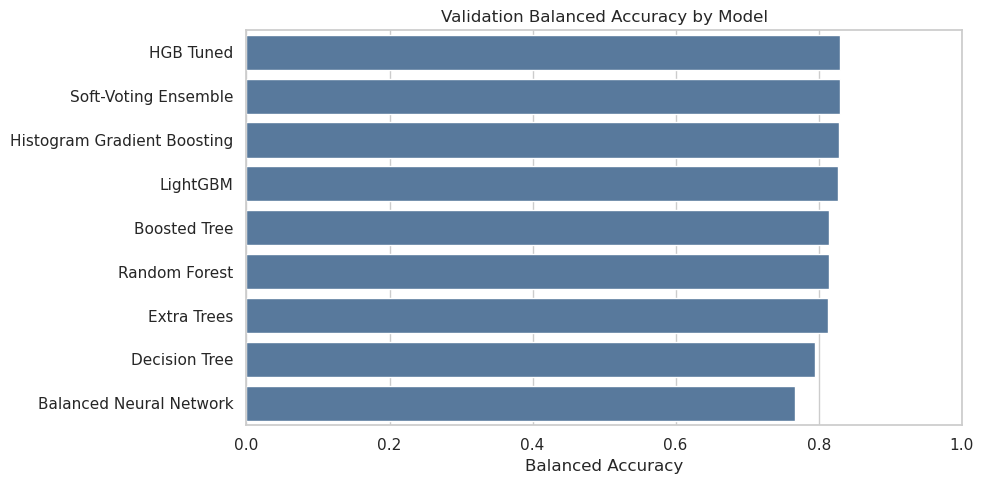

In [24]:
# Compare all validation metrics collected from the model sections above.
comparison_columns = ["Model", "Threshold", "Balanced Accuracy", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
model_comparison = pd.DataFrame(model_results)[comparison_columns].sort_values(
    by="Balanced Accuracy",
    ascending=False,
).reset_index(drop=True)

display(model_comparison.style.format({
    "Threshold": "{:.3f}",
    "Balanced Accuracy": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}",
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison, x="Balanced Accuracy", y="Model", color="#4C78A8")
plt.title("Validation Balanced Accuracy by Model")
plt.xlim(0, 1)
plt.xlabel("Balanced Accuracy")
plt.ylabel("")
plt.tight_layout()
plt.show()
